# 03 — Explainability

**Goal:** open the black box. The best baseline (histogram gradient boosting on raw features,
PR-AUC 0.835) clearly learned *something*. This notebook uses SHAP to find out *what*, and turns the
findings into precise, testable hypotheses for M4.

**SHAP in one paragraph:** for every prediction, SHAP splits the model output into one contribution
per feature. The contributions add up exactly to the model output, starting from a base value (the
average prediction). Here the output is in **log-odds of failure**: positive values push towards
"failure", negative values push towards "no failure". A contribution of +2 roughly multiplies the
odds of failure by e² ≈ 7.

**Setup:** we fit the model on the full dataset and explain that model. This is fine because the
goal is to understand the learned patterns. Performance was already measured out-of-fold in M2.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from matplotlib.colors import TwoSlopeNorm

from pdm.config import FIGURES_DIR, PROJECT_ROOT
from pdm.data import FAILURE_MODES, FEATURES, NUMERIC_FEATURES, TARGET, load_data
from pdm.evaluate import make_cv
from pdm.explain import explain
from pdm.models import baseline_models

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"No failure": "#8d99ae", "Failure": "#d1495b"}
SHAP_CMAP = "coolwarm"


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"03_{name}.png", dpi=150, bbox_inches="tight")

In [2]:
df = load_data()
X, y = df[FEATURES], df[TARGET]

model = baseline_models()["HistGradientBoosting"].fit(X, y)
exp = explain(model, X)
shap_df = pd.DataFrame(exp.values, columns=FEATURES, index=X.index)

print(f"Base value (average log-odds): {exp.base_values[0]:.2f}")
print(f"  = failure probability {1 / (1 + np.exp(-exp.base_values[0])):.2%}")

Base value (average log-odds): -7.95
  = failure probability 0.04%


The base value is the *average log-odds* over all rows, not the log-odds of the average
probability. Most rows get a very confident "no failure" prediction, so the average sits far below
the 3.4% failure rate. A row needs several strong positive contributions before the model predicts a
failure.

## 1. Global feature importance

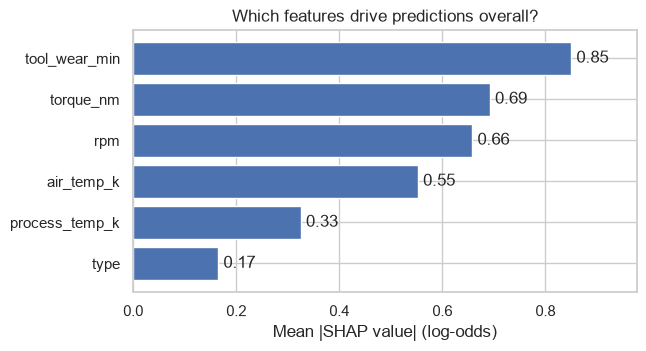

In [3]:
importance = shap_df.abs().mean().sort_values()

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.barh(importance.index, importance.values, color="#4c72b0")
for i, v in enumerate(importance.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center")
ax.set_xlim(0, importance.max() * 1.15)
ax.set_xlabel("Mean |SHAP value| (log-odds)")
ax.set_title("Which features drive predictions overall?")
save(fig, "importance")
plt.show()

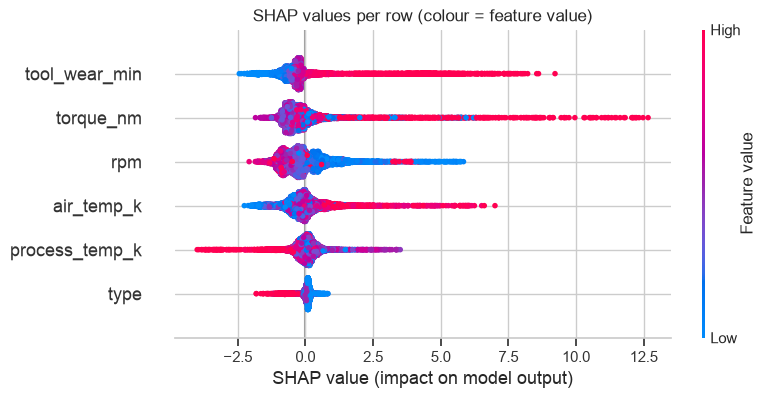

In [4]:
shap.plots.beeswarm(exp, max_display=len(FEATURES), show=False)
fig = plt.gcf()
fig.set_size_inches(8, 4)
plt.title("SHAP values per row (colour = feature value)")
save(fig, "beeswarm")
plt.show()

- **Tool wear** has the highest average impact, followed by **torque** and **rotational speed**.
- **Air temperature** matters more than process temperature, which is surprising on its own, since
  the EDA showed only small temperature shifts. It hints that the temperatures act in combination.
- **Machine type** has the smallest effect overall.
- The beeswarm shows long tails to the right: most rows get small negative contributions, and a few
  rows get very large positive ones. The model has learned **sharp failure regions**, not smooth trends.

Global importance says *which* features matter, not *how*. The next sections look at the shape of
each effect.

## 2. Single-feature effects

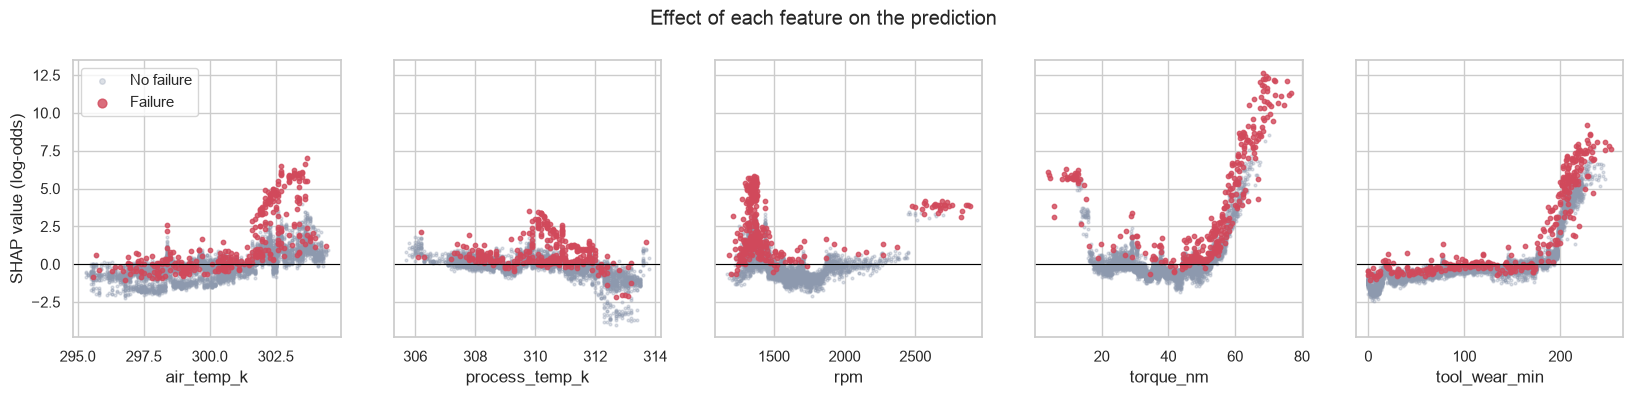

In [5]:
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(20, 3.6), sharey=True)
for ax, col in zip(axes, NUMERIC_FEATURES, strict=True):
    for label, mask in [("No failure", y == 0), ("Failure", y == 1)]:
        ax.scatter(
            X.loc[mask, col],
            shap_df.loc[mask, col],
            s=4 if label == "No failure" else 10,
            alpha=0.3 if label == "No failure" else 0.8,
            color=COLORS[label],
            label=label,
        )
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel(col)
axes[0].set_ylabel("SHAP value (log-odds)")
axes[0].legend(loc="upper left", markerscale=2)
fig.suptitle("Effect of each feature on the prediction", y=1.02)
save(fig, "dependence")
plt.show()

- **Tool wear:** almost no effect until about 180–200 minutes, then a steep rise.
- **Torque:** strong effect at both ends, very low *and* very high torque.
- **Rotational speed:** the same at both ends, low speed and very high speed.
- **Temperatures:** high air temperature pushes towards failure, and high process temperature pushes
  away from it. Together that suggests the *difference* between the two matters.

Each single-feature plot shows a lot of vertical spread at the same x value, meaning the same value
can push the prediction up or down depending on the other features. That is the signature of
**interactions**. The next three sections look at the pairs that interact.

## 3. Hypothesis 1: speed × torque

Torque and speed are both involved at their extremes, and the EDA showed failures at the two ends of
the speed-torque band. In mechanics, torque and speed combine into **power**:

$$P\,[\text{W}] = \tau\,[\text{Nm}] \cdot \omega\,[\text{rad/s}] = \tau \cdot \text{rpm} \cdot \frac{2\pi}{60}$$

If the model has learned a power limit, the joint contribution of speed and torque should be
constant along lines of equal power.

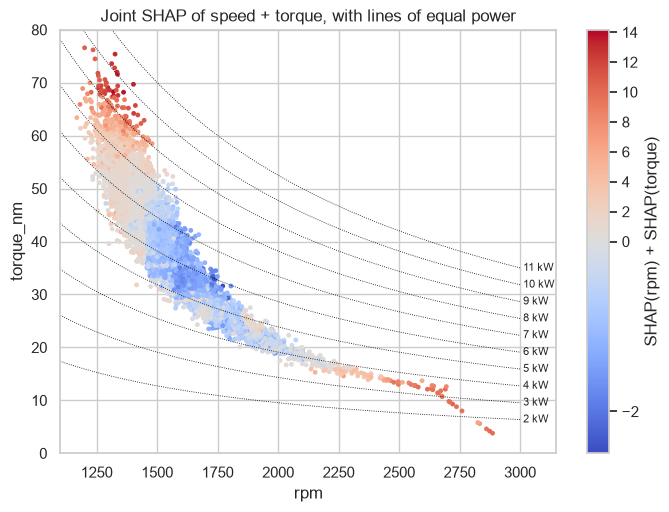

In [6]:
def power_w(torque_nm, rpm):
    return torque_nm * rpm * 2 * np.pi / 60


df["power_w"] = power_w(df["torque_nm"], df["rpm"])
joint_power = shap_df["rpm"] + shap_df["torque_nm"]

fig, ax = plt.subplots(figsize=(8, 5.5))
norm = TwoSlopeNorm(vcenter=0, vmin=joint_power.min(), vmax=joint_power.max())
sc = ax.scatter(df["rpm"], df["torque_nm"], c=joint_power, cmap=SHAP_CMAP, norm=norm, s=6)
rpm_grid = np.linspace(1100, 3000, 300)
for p in range(2000, 11001, 1000):
    torque = p / (rpm_grid * 2 * np.pi / 60)
    ax.plot(rpm_grid, torque, color="black", lw=0.6, ls=":")
    ax.text(3000, p / (3000 * 2 * np.pi / 60), f" {p / 1000:.0f} kW", va="center", fontsize=8)
ax.set_xlim(1100, 3150)
ax.set_ylim(0, 80)
ax.set_xlabel("rpm")
ax.set_ylabel("torque_nm")
ax.set_title("Joint SHAP of speed + torque, with lines of equal power")
fig.colorbar(sc, ax=ax, label="SHAP(rpm) + SHAP(torque)")
save(fig, "h1_power")
plt.show()

In [7]:
power_bins = pd.cut(df["power_w"], [0, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000])
pd.DataFrame(
    {
        "rows": power_bins.value_counts(sort=False),
        "mean joint SHAP": joint_power.groupby(power_bins, observed=True).mean(),
        "failure rate": y.groupby(power_bins, observed=True).mean(),
    }
).style.format({"mean joint SHAP": "{:+.2f}", "failure rate": "{:.1%}"})

,rows,mean joint SHAP,failure rate
power_w,,,
"(0, 3000]",11,+9.21,100.0%
"(3000, 4000]",141,+3.02,14.9%
"(4000, 5000]",981,-0.44,0.8%
"(5000, 6000]",2831,-0.95,0.7%
"(6000, 7000]",3528,-0.34,1.6%
"(7000, 8000]",1958,+0.71,4.6%
"(8000, 9000]",486,+3.50,14.2%
"(9000, 10000]",58,+10.58,100.0%
"(10000, 20000]",6,+12.97,100.0%


The red regions follow the iso-power lines instead of vertical (speed) or horizontal (torque)
boundaries. The table confirms it:

- Between 4 and 8 kW, the joint contribution is close to zero and failures are rare.
- Below 3 kW or above 9 kW, **every** process fails and the contribution is extreme.
- The 3–4 kW and 8–9 kW bins are transition zones, where about 15% of rows fail.
  The exact limits lie somewhere inside these bins.

> **H1 (power failure):** a process fails when the mechanical power leaves a window of roughly
> 3.5 to 9 kW.

## 4. Hypothesis 2: tool wear × torque

Tool wear only matters above about 200 minutes, and high torque matters too. A worn tool under
high load is a classic overstrain scenario. If the model has learned a limit on the **product** of
wear and torque, the joint contribution should follow hyperbolas `tool_wear × torque = const`.

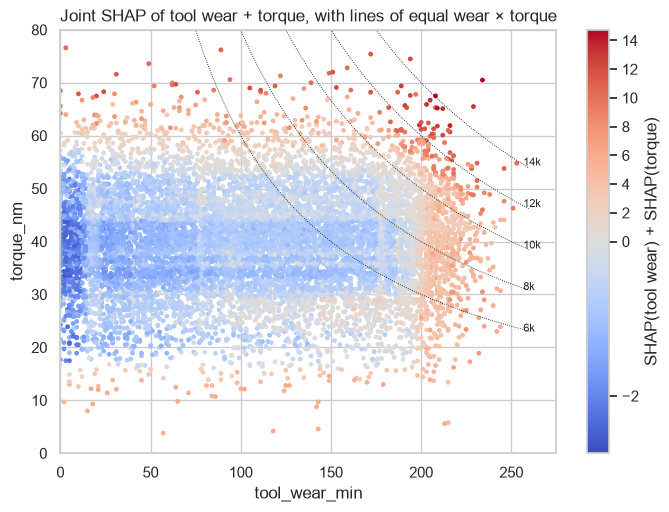

In [8]:
df["strain"] = df["tool_wear_min"] * df["torque_nm"]
joint_strain = shap_df["tool_wear_min"] + shap_df["torque_nm"]

fig, ax = plt.subplots(figsize=(8, 5.5))
norm = TwoSlopeNorm(vcenter=0, vmin=joint_strain.min(), vmax=joint_strain.max())
sc = ax.scatter(
    df["tool_wear_min"], df["torque_nm"], c=joint_strain, cmap=SHAP_CMAP, norm=norm, s=6
)
wear_grid = np.linspace(60, 260, 300)
for s in [6000, 8000, 10000, 12000, 14000]:
    ax.plot(wear_grid, s / wear_grid, color="black", lw=0.6, ls=":")
    ax.text(255, s / 255, f" {s / 1000:.0f}k", va="center", fontsize=8)
ax.set_xlim(0, 275)
ax.set_ylim(0, 80)
ax.set_xlabel("tool_wear_min")
ax.set_ylabel("torque_nm")
ax.set_title("Joint SHAP of tool wear + torque, with lines of equal wear × torque")
fig.colorbar(sc, ax=ax, label="SHAP(tool wear) + SHAP(torque)")
save(fig, "h2_strain")
plt.show()

In [9]:
strain_bins = pd.cut(df["strain"], [0, 6000, 8000, 9000, 10000, 11000, 12000, 13000, 30000])
table = pd.DataFrame({"s": joint_strain, "type": df["type"], "bin": strain_bins})
table.pivot_table(
    index="bin", columns="type", values="s", aggfunc="mean", observed=True
).style.format("{:+.2f}", na_rep="–")

type,L,M,H
bin,,,
"(0, 6000]",-0.50,-0.44,-0.55
"(6000, 8000]",+0.39,+0.52,+0.48
"(8000, 9000]",+1.25,+1.06,+1.20
"(9000, 10000]",+1.91,+1.47,+2.18
"(10000, 11000]",+3.86,+3.50,+2.75
"(11000, 12000]",+8.88,+5.94,+7.93
"(12000, 13000]",+11.14,+10.83,–
"(13000, 30000]",+12.87,+12.39,+11.23


This picture is noisier than H1, because the joint contribution also contains two other effects:

- the power effect of torque (the red band at high torque, at any tool wear)
- the general tool wear effect above about 200 minutes, where tool wear failures happen

The darkest region is in the upper right, beyond the 10–12k hyperbolas. The table isolates the
pattern: the joint contribution grows gradually from about 8k min·Nm, then jumps above about
11k min·Nm.

The table is split by machine type, because the EDA showed that overstrain is almost exclusively an
L problem. The data for M and H is thin at high strain, so the model cannot show clearly whether the
limit differs by type. M4 tests this directly.

> **H2 (overstrain failure):** a process fails when tool wear × torque exceeds roughly
> 11k min·Nm, possibly with a higher limit for better machine types.

## 5. Hypothesis 3: temperature difference × speed

High air temperature and low process temperature both push towards failure, so the relevant quantity
may be the **difference** between them. Physically, heat can only flow from the process to the air
if the process is warmer, so a small difference means poor heat dissipation. Speed may matter too,
since a slower spindle moves less air and removes less heat.

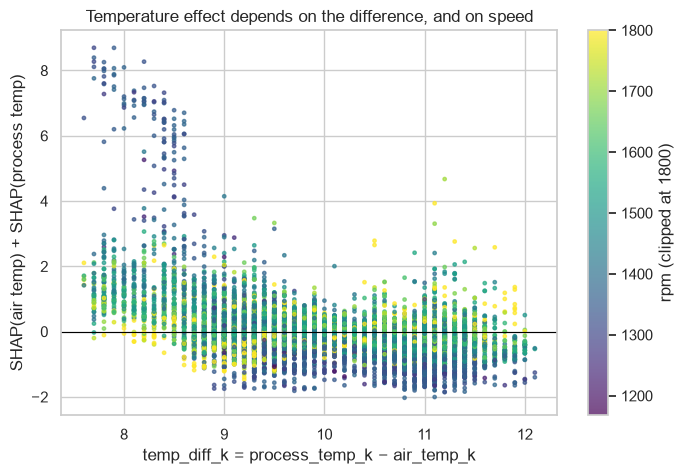

In [10]:
df["temp_diff_k"] = df["process_temp_k"] - df["air_temp_k"]
joint_temp = shap_df["air_temp_k"] + shap_df["process_temp_k"]

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    df["temp_diff_k"],
    joint_temp,
    c=df["rpm"].clip(upper=1800),
    cmap="viridis",
    s=6,
    alpha=0.7,
)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("temp_diff_k = process_temp_k − air_temp_k")
ax.set_ylabel("SHAP(air temp) + SHAP(process temp)")
ax.set_title("Temperature effect depends on the difference, and on speed")
fig.colorbar(sc, ax=ax, label="rpm (clipped at 1800)")
save(fig, "h3_heat")
plt.show()

In [11]:
temp_bins = pd.cut(df["temp_diff_k"], [7, 8, 8.5, 9, 9.5, 10, 12])
rpm_bins = pd.cut(df["rpm"], [0, 1300, 1400, 1500, 3000])
table = pd.DataFrame({"s": joint_temp, "temp": temp_bins, "rpm": rpm_bins})
table.pivot_table(
    index="temp", columns="rpm", values="s", aggfunc="mean", observed=True
).style.format("{:+.2f}", na_rep="–")

rpm,"(0, 1300]","(1300, 1400]","(1400, 1500]","(1500, 3000]"
temp,,,,
"(7.0, 8.0]",+3.60,+5.82,+1.45,+1.11
"(8.0, 8.5]",+4.55,+4.84,+1.38,+0.74
"(8.5, 9.0]",+0.63,+0.70,+0.32,+0.14
"(9.0, 9.5]",-0.02,-0.25,+0.09,+0.08
"(9.5, 10.0]",-0.71,-0.55,-0.07,-0.04
"(10.0, 12.0]",-0.93,-0.80,-0.26,-0.15


Plotted against the temperature *difference*, the two temperature contributions collapse onto a
clear pattern:

- Above about 9 K difference, the temperatures push towards "no failure".
- Below about 8.5 K, the contribution rises sharply, **but only for slow spindles** (dark points)
  below about 1,400 rpm.
  At high speed, even a small temperature difference is harmless.

This is an **AND condition** between two quantities. Trees can express that, but only through many
splits on the raw temperatures.

> **H3 (heat dissipation failure):** a process fails when the temperature difference is below
> roughly 8.5 K **and** the rotational speed is below roughly 1,400 rpm.

## 6. Individual predictions

SHAP also explains single predictions, and the Streamlit demo (M7) will use exactly this view.
Two examples, using the out-of-fold probabilities and the best-F1 threshold from M2.

**Important:** the model fitted on all rows has already seen these examples and partly memorised
their labels, so explaining it would be misleading. Instead, each example is explained with the
**cross-validation model that never saw it**, which is the same model that produced its out-of-fold
probability in M2.

1. a failure with only the heat dissipation mode that the model **caught**
2. a tool wear failure that the model **missed**

In [12]:
oof = pd.read_csv(PROJECT_ROOT / "reports" / "02_baseline_oof.csv")
threshold = pd.read_csv(
    PROJECT_ROOT / "reports" / "02_baseline_results.csv", index_col="model"
).loc["HistGradientBoosting", "threshold"]
df["oof_proba"] = oof["proba_HistGradientBoosting"].to_numpy()

only_hdf = (df["hdf"] == 1) & (df[list(FAILURE_MODES)].sum(axis=1) == 1)
caught_hdf = df[only_hdf & (df["oof_proba"] >= threshold)]["oof_proba"].idxmax()
missed_twf = df[(df["twf"] == 1) & (df["oof_proba"] < threshold)]["oof_proba"].idxmin()

cols = ["type", *NUMERIC_FEATURES, "temp_diff_k", "power_w", "strain", "oof_proba"]
examples = df.loc[[caught_hdf, missed_twf], cols].round(2)
examples.index = ["Caught HDF", "Missed TWF"]
print(f"Decision threshold: {threshold:.3f}")
examples

Decision threshold: 0.288


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,temp_diff_k,power_w,strain,oof_proba
Caught HDF,L,302.3,310.1,1353,50.9,36,7.8,7211.81,1832.4,1.0
Missed TWF,L,297.8,308.9,1871,25.6,200,11.1,5015.82,5120.0,0.0


caught_hdf: fold model probability 0.999 (OOF from M2: 0.999)


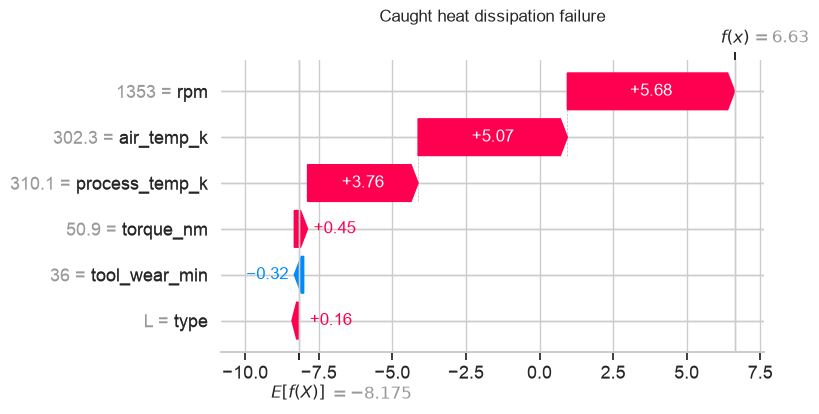

missed_twf: fold model probability 0.000 (OOF from M2: 0.000)


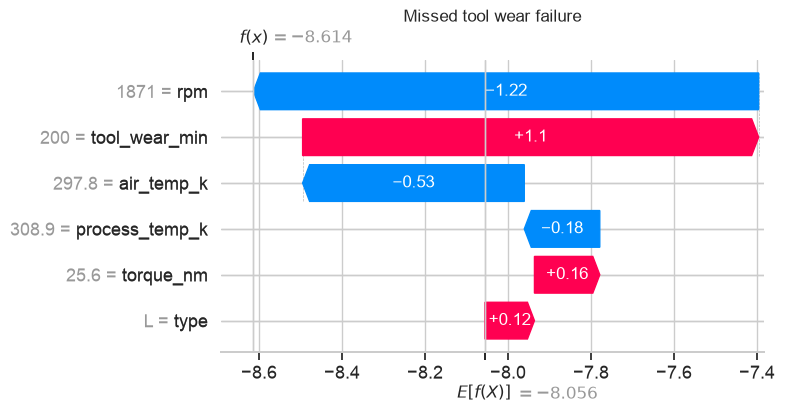

In [13]:
folds = list(make_cv().split(X, y))


def fold_model_for(idx):
    # Refit the M2 cross-validation model whose test fold contains row `idx`
    pos = X.index.get_loc(idx)
    train = next(train for train, test in folds if pos in test)
    return baseline_models()["HistGradientBoosting"].fit(X.iloc[train], y.iloc[train])


for idx, name in [(caught_hdf, "caught_hdf"), (missed_twf, "missed_twf")]:
    fold_model = fold_model_for(idx)
    proba = fold_model.predict_proba(X.loc[[idx]])[0, 1]
    print(
        f"{name}: fold model probability {proba:.3f} (OOF from M2: {df.loc[idx, 'oof_proba']:.3f})"
    )
    shap.plots.waterfall(
        explain(fold_model, X.loc[[idx]])[0], max_display=len(FEATURES), show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(7, 3.8)
    title = (
        "Caught heat dissipation failure" if name == "caught_hdf" else "Missed tool wear failure"
    )
    plt.title(title)
    save(fig, f"waterfall_{name}")
    plt.show()

- **Caught HDF:** small temperature difference and low speed. Both temperatures and the speed push
  the prediction strongly towards failure, which matches H3 exactly.
- **Missed TWF:** the tool is at 200 minutes of wear, so tool wear pushes towards failure. But the
  speed, temperatures and torque are all in their normal ranges and pull the prediction back down.
  Thousands of processes with similar wear did *not* fail. Tool wear failures happen at a random
  moment within the high-wear range, and the sensors carry no signal about *when*. No model can
  reliably predict these from this data.

**Lesson learned:** the model fitted on all rows gives this same row about 68% failure probability,
because it has seen the row and memorised its label. Explaining a model on its own training data can
tell a convincing but false story. Always explain the prediction that was actually made.

## 7. Hypotheses for M4

The model has learned three sharp failure regions. Each one is a combination of raw features that a
tree can only approximate with many splits:

| # | Failure mode | Derived quantity | Hypothesised rule |
|---|---|---|---|
| H1 | Power failure | `power_w = torque · rpm · 2π/60` | fails if power < ~3.5 kW or > ~9 kW |
| H2 | Overstrain failure | `strain = tool_wear · torque` | fails if strain > ~11k min·Nm (maybe type-dependent) |
| H3 | Heat dissipation failure | `temp_diff_k = process − air temperature` | fails if temp diff < ~8.5 K **and** rpm < ~1,400 |

Tool wear failures, random failures and failures without a mode showed no learnable pattern.

**Next (M4):** compute these features explicitly, estimate exact thresholds from the data, check
each rule against its failure-mode label, and compare:

1. raw-feature ML (M2)
2. rules only
3. ML with physics features
4. a hybrid of rules and ML